In [ ]:
!pip install bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.5 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Kaggle-Womens Clothing E-Commerce Reviews.csv to Kaggle-Womens Clothing E-Commerce Reviews.csv


Data loaded: 23486 rows
Preprocessing done.

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.

Processing Gen Z (18-27)...
  Done. Topics found: 5

Processing Millennials (28-43)...
  Done. Topics found: 5

Processing Gen X (44-59)...
  Done. Topics found: 5

Processing Baby Boomers (60+)...
  Done. Topics found: 1


Gen Z (18-27) (n=1990)
----------------------------------------
  Topic 0 (980 docs): dress, love, fit, size, great, wear
  Topic 1 (146 docs): love, looks, colors, look, color, good
  Topic 2 (60 docs): nan, , , , , 
  Topic 3 (14 docs): measurements, photos, reference, wearing, medium, purchase
  Topic 4 (11 docs): romper, great, black, rompers, wear, trying

Millennials (28-43) (n=11231)
----------------------------------------
  Topic 0 (5439 docs): love, size, fit, great, wear, dress
  Topic 1 (495 docs): nan, , , , , 
  Topic 2 (19 docs): stain, pair, dye, washed, detergent, pants
  Topic 3 (15 docs): cropped, length, sweater, cute, picture, model
  Topic 4 (14 docs): cozy, warm, love, comfy, lounging, comfortable

Gen X (44-59) (n=7487)
-------

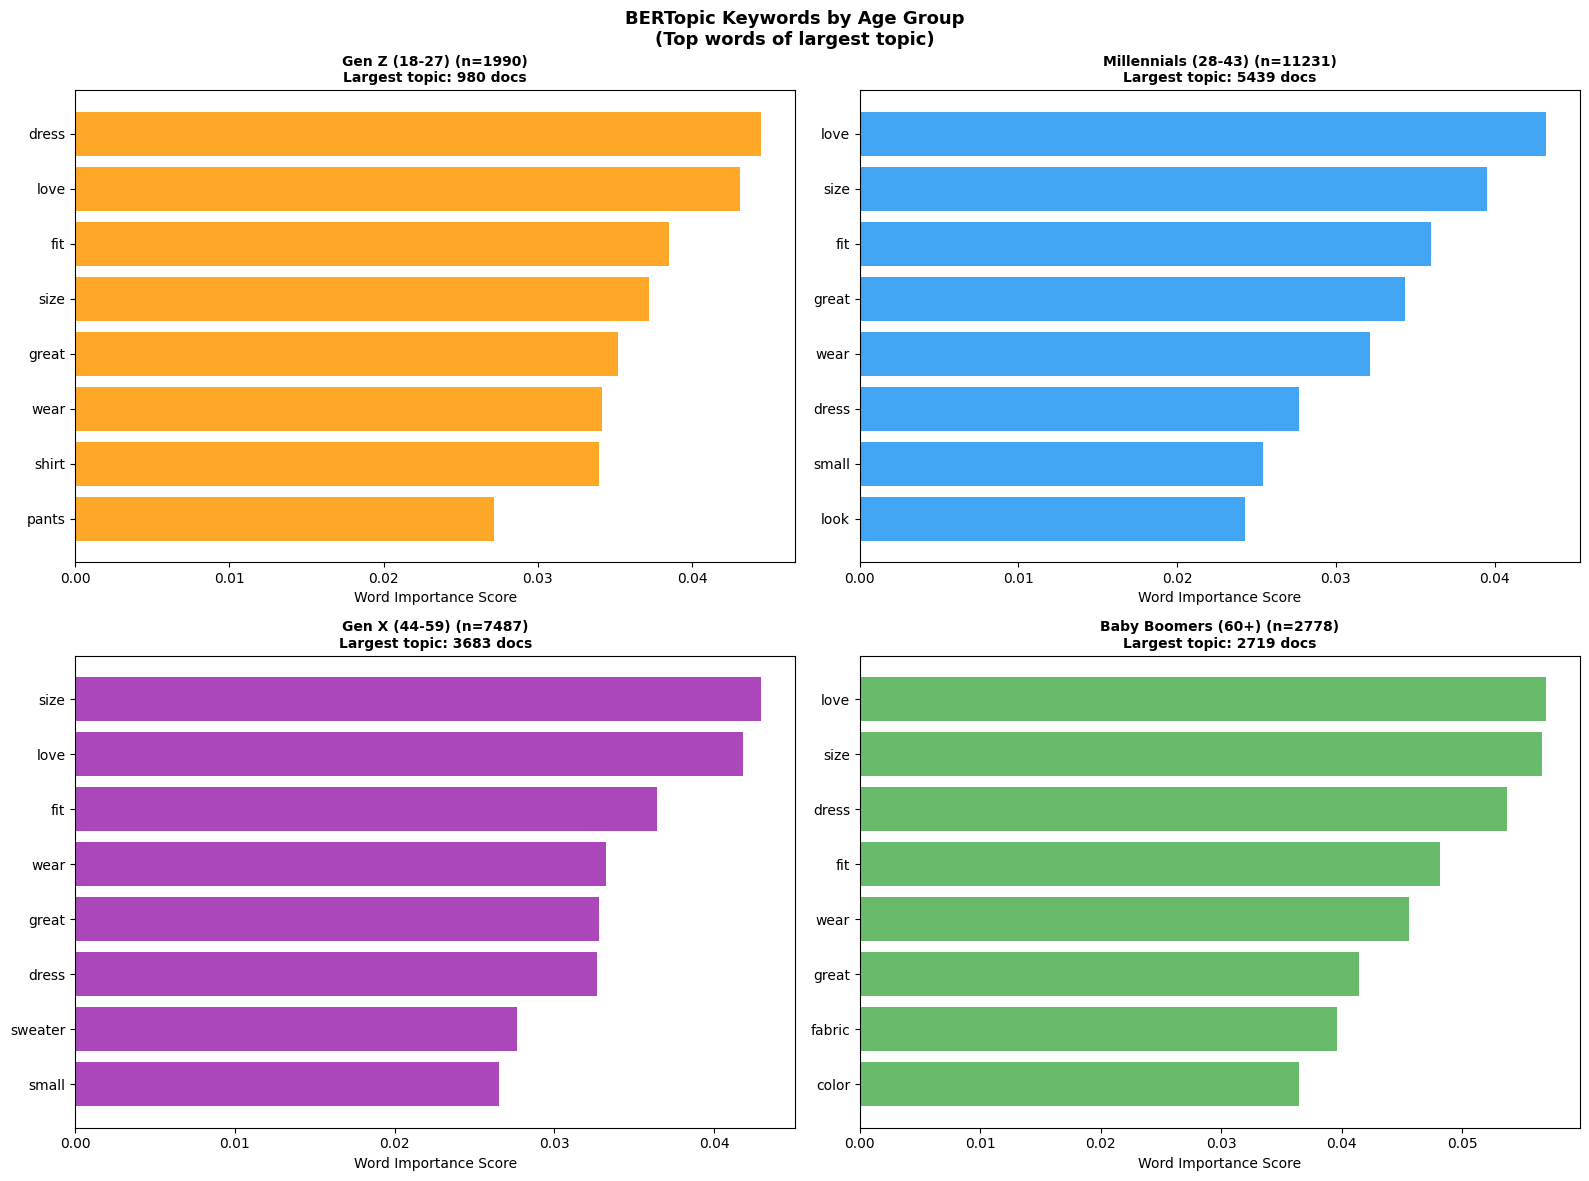

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done!


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import os

# ── Load data ─────────────────────────────────────────────────────────────────
csv_files = [f for f in os.listdir("/content") if f.endswith(".csv")]
df = pd.read_csv(f"/content/{csv_files[0]}")
print(f"Data loaded: {len(df)} rows")

# ── Define age groups ─────────────────────────────────────────────────────────
bins   = [0, 27, 43, 59, 100]
labels = ["Gen Z (18-27)", "Millennials (28-43)",
          "Gen X (44-59)", "Baby Boomers (60+)"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

# ── Text preprocessing ────────────────────────────────────────────────────────
stop_words = [
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "this", "that", "it", "is", "was", "are", "were", "be",
    "been", "have", "has", "had", "do", "did", "will", "would", "could",
    "should", "may", "might", "i", "my", "me", "we", "our", "you", "your",
    "they", "their", "them", "he", "she", "his", "her", "its", "not", "no",
    "so", "if", "as", "by", "from", "up", "about", "into", "than", "just",
    "also", "very", "really", "got", "get", "one", "like", "im", "ive",
    "dont", "didnt", "thats", "though", "even", "still", "much", "more",
    "all", "can", "when", "what", "how", "there", "then", "too", "out",
    "who", "which", "some", "am", "us", "these", "those", "such",
    "after", "before", "where", "while", "back", "only", "but"
]

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df["Clean Text"] = df["Review Text"].apply(preprocess)
df = df.dropna(subset=["Clean Text", "Age Group"])
print("Preprocessing done.")

# ── Load embedding model ──────────────────────────────────────────────────────
print("\nLoading embedding model...")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded.")

# ── Run BERTopic for each age group ───────────────────────────────────────────
results = {}

for group in labels:
    print(f"\nProcessing {group}...")
    group_df = df[df["Age Group"] == group]
    texts    = group_df["Clean Text"].tolist()

    vectorizer_model = CountVectorizer(
        stop_words="english",
        min_df=1,
        max_df=1.0,
        ngram_range=(1, 1)
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        nr_topics=6,
        min_topic_size=10,
        language="english",
        calculate_probabilities=False,
        verbose=False
    )

    topics, _ = topic_model.fit_transform(texts)

    results[group] = {
        "model": topic_model,
        "topics": topics,
        "n": len(group_df)
    }
    print(f"  Done. Topics found: {len(set(topics))-1}")

# ── Print top topics per group ────────────────────────────────────────────────
print("\n" + "=" * 55)
for group in labels:
    model      = results[group]["model"]
    topic_info = model.get_topic_info()
    topic_info = topic_info[topic_info["Topic"] != -1].head(5)
    print(f"\n{group} (n={results[group]['n']})")
    print("-" * 40)
    for _, row in topic_info.iterrows():
        words = [w for w, _ in model.get_topic(row["Topic"])][:6]
        print(f"  Topic {row['Topic']} ({row['Count']} docs): {', '.join(words)}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("BERTopic Keywords by Age Group\n(Top words of largest topic)",
             fontsize=13, fontweight="bold")

colors = ["#FF9800", "#2196F3", "#9C27B0", "#4CAF50"]

for ax, group, color in zip(axes.flatten(), labels, colors):
    model      = results[group]["model"]
    topic_info = model.get_topic_info()
    topic_info = topic_info[topic_info["Topic"] != -1]

    if len(topic_info) == 0:
        ax.set_title(f"{group}\nNo topics found")
        continue

    valid_words = []
    for _, row in topic_info.iterrows():
        topic_words = model.get_topic(row["Topic"])
        if topic_words and topic_words[0][0] != "nan":
            valid_words = topic_words[:8]
            topic_count = row["Count"]
            break

    if not valid_words:
        ax.set_title(f"{group}\nNo valid topics found")
        continue

    words   = [w for w, _ in valid_words]
    weights = [v for _, v in valid_words]

    ax.barh(words[::-1], weights[::-1], color=color, alpha=0.85)
    ax.set_title(f"{group} (n={results[group]['n']})\n"
                 f"Largest topic: {topic_count} docs",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Word Importance Score")

plt.tight_layout()
plt.savefig("bertopic_age_groups_final.png", dpi=150)
plt.show()

from google.colab import files
files.download("bertopic_age_groups_final.png")
print("\nDone!")

Unique keywords per group:
  Gen Z (18-27): ['shirt', 'pants']
  Millennials (28-43): ['look']
  Gen X (44-59): ['sweater']
  Baby Boomers (60+): ['fabric', 'color']


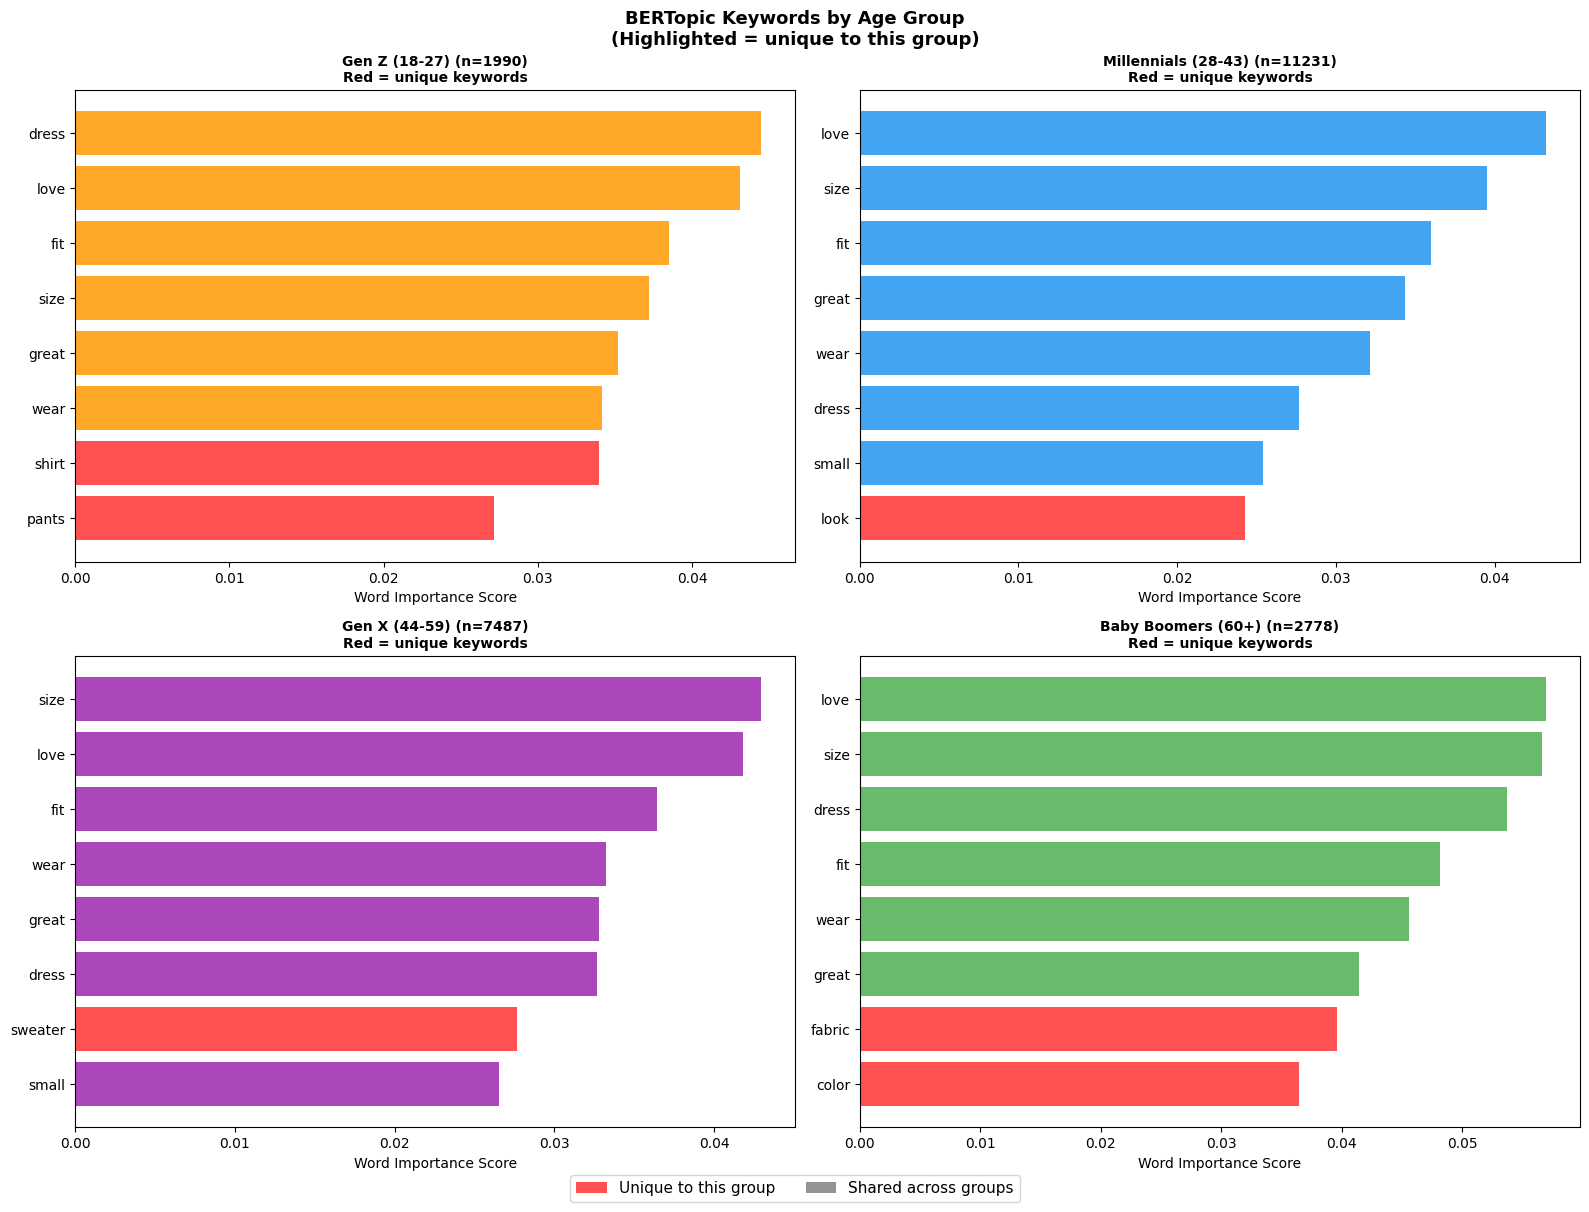

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done!


In [ ]:
# ── Find unique keywords per group ───────────────────────────────────────────
# Extract top 8 words from largest topic for each group
group_words = {}
for group in labels:
    model      = results[group]["model"]
    topic_info = model.get_topic_info()
    topic_info = topic_info[topic_info["Topic"] != -1]

    for _, row in topic_info.iterrows():
        topic_words = model.get_topic(row["Topic"])
        if topic_words and topic_words[0][0] != "nan":
            group_words[group] = {w: v for w, v in topic_words[:8]}
            break

# Find unique words per group (not appearing in other groups' top words)
all_words = {}
for group, words in group_words.items():
    for w in words:
        all_words[w] = all_words.get(w, 0) + 1

unique_words = {group: [w for w in words if all_words[w] == 1]
                for group, words in group_words.items()}

print("Unique keywords per group:")
for group, words in unique_words.items():
    print(f"  {group}: {words}")

# ── Visualization with unique words highlighted ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("BERTopic Keywords by Age Group\n(Highlighted = unique to this group)",
             fontsize=13, fontweight="bold")

colors      = ["#FF9800", "#2196F3", "#9C27B0", "#4CAF50"]
highlight   = "#FF3333"  # red for unique words

for ax, group, color in zip(axes.flatten(), labels, colors):
    words   = list(group_words[group].keys())
    weights = list(group_words[group].values())
    unique  = unique_words[group]

    bar_colors = [highlight if w in unique else color for w in words]

    bars = ax.barh(words[::-1], weights[::-1], color=bar_colors[::-1], alpha=0.85)
    ax.set_title(f"{group} (n={results[group]['n']})\n"
                 f"Red = unique keywords",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Word Importance Score")

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#FF3333", alpha=0.85, label="Unique to this group"),
    Patch(facecolor="gray",    alpha=0.85, label="Shared across groups")
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("bertopic_unique_keywords.png", dpi=150, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("bertopic_unique_keywords.png")
print("\nDone!")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Kaggle-Womens Clothing E-Commerce Reviews.csv to Kaggle-Womens Clothing E-Commerce Reviews.csv
Saving reddit_comments.csv to reddit_comments.csv


In [ ]:
!pip install bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.9 MB/s eta 0:00:00


E-commerce: 23486 rows
Reddit: 2662 rows

After preprocessing:
  E-commerce: 22641 texts
  Reddit: 2662 texts

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.

Processing E-commerce...
  Done. Topics found: 9

Processing Reddit...
  Done. Topics found: 9


E-commerce (n=22641)
----------------------------------------
  Topic 0 (14066 docs): size, dress, fit, small, sweater, shirt
  Topic 1 (124 docs): romper, rompers, short, long, fit, shorts
  Topic 2 (114 docs): buttons, button, dress, little, open, tried
  Topic 3 (71 docs): poncho, cozy, warm, ponchos, cold, weather
  Topic 4 (57 docs): pants, dye, wash, pair, stain, smell
  Topic 5 (54 docs): collar, neck, way, neckline, shoulders, large
  Topic 6 (39 docs): cords, pair, fit, size, pants, grey
  Topic 7 (36 docs): tts, fits, fit, loose, offwhite, length

Reddit (n=2662)
----------------------------------------
  Topic 0 (1043 docs): buy, bought, pair, quality, leggings, years
  Topic 1 (272 docs): wear, people, look, trends, dress, style
  Topic 2 (155 docs): warm, coat, winter, wool, cold, mens
  Topic 3 (100 docs): app, post, trip, stylebook, using, spreadsheet
  Topic 4

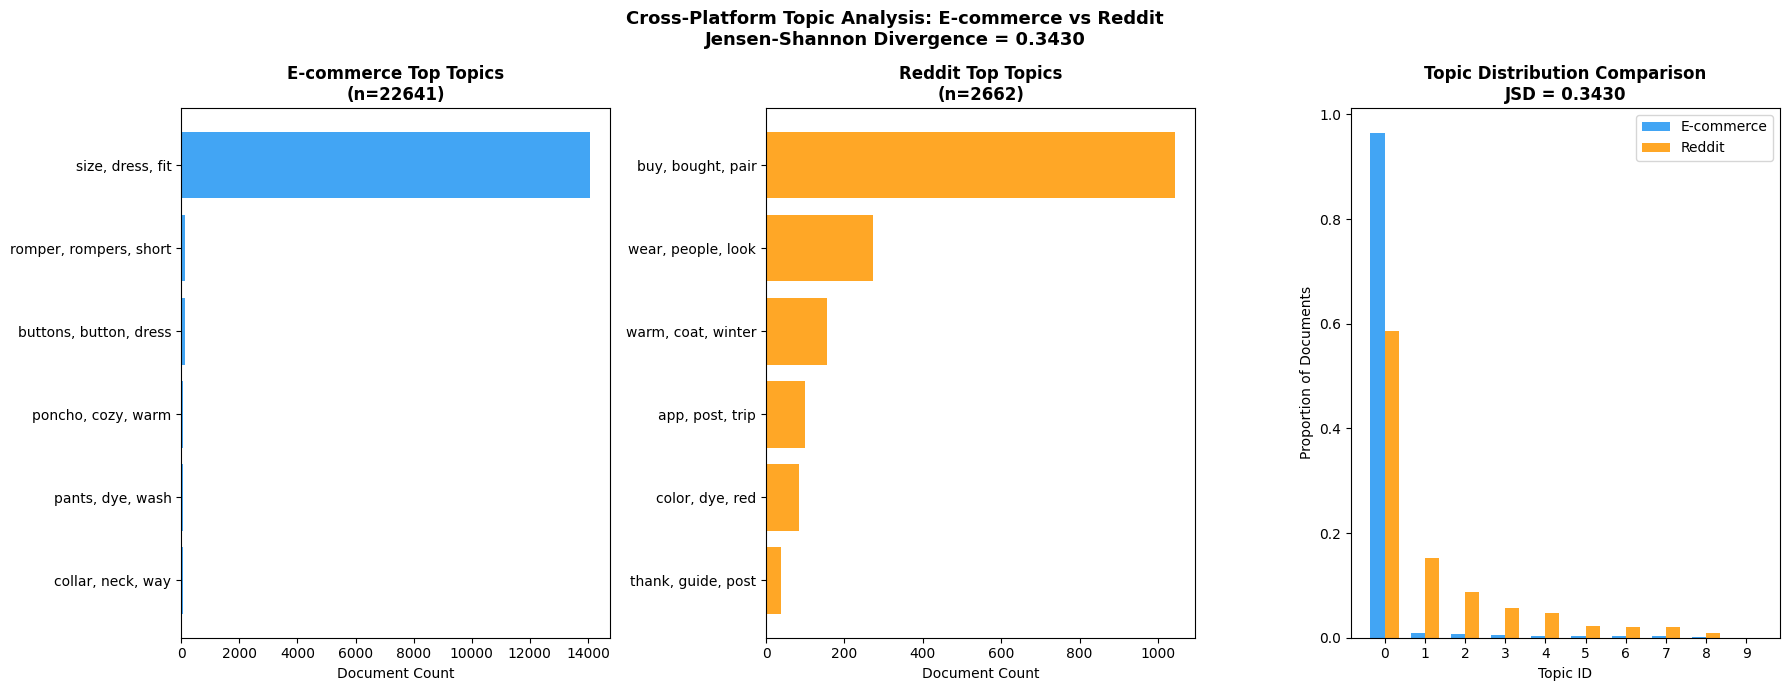

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done!


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from scipy.spatial.distance import jensenshannon
import os

# ── Load data ─────────────────────────────────────────────────────────────────
ec_df     = pd.read_csv("/content/Kaggle-Womens Clothing E-Commerce Reviews.csv")
reddit_df = pd.read_csv("/content/reddit_comments.csv")
print(f"E-commerce: {len(ec_df)} rows")
print(f"Reddit: {len(reddit_df)} rows")

# ── Text preprocessing ────────────────────────────────────────────────────────
stop_words = [
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "this", "that", "it", "is", "was", "are", "were", "be",
    "been", "have", "has", "had", "do", "did", "will", "would", "could",
    "should", "may", "might", "i", "my", "me", "we", "our", "you", "your",
    "they", "their", "them", "he", "she", "his", "her", "its", "not", "no",
    "so", "if", "as", "by", "from", "up", "about", "into", "than", "just",
    "also", "very", "really", "got", "get", "one", "like", "im", "ive",
    "dont", "didnt", "thats", "though", "even", "still", "much", "more",
    "all", "can", "when", "what", "how", "there", "then", "too", "out",
    "who", "which", "some", "am", "us", "these", "those", "such",
    "after", "before", "where", "while", "back", "only", "but"
]

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

ec_texts     = ec_df["Review Text"].dropna().apply(preprocess).tolist()
reddit_texts = reddit_df["comment"].dropna().apply(preprocess).tolist()
print(f"\nAfter preprocessing:")
print(f"  E-commerce: {len(ec_texts)} texts")
print(f"  Reddit: {len(reddit_texts)} texts")

# ── Load embedding model ──────────────────────────────────────────────────────
print("\nLoading embedding model...")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded.")

# ── Run BERTopic on each platform ─────────────────────────────────────────────
platforms = {
    "E-commerce": ec_texts,
    "Reddit":     reddit_texts
}
results = {}

for platform, texts in platforms.items():
    print(f"\nProcessing {platform}...")

    vectorizer_model = CountVectorizer(
        stop_words="english",
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 1)
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        nr_topics=10,
        min_topic_size=15,
        language="english",
        calculate_probabilities=True,
        verbose=False
    )

    topics, probs = topic_model.fit_transform(texts)

    results[platform] = {
        "model":  topic_model,
        "topics": topics,
        "probs":  probs,
        "n":      len(texts)
    }
    print(f"  Done. Topics found: {len(set(topics))-1}")

# ── Print top topics per platform ─────────────────────────────────────────────
print("\n" + "=" * 55)
for platform in platforms:
    model      = results[platform]["model"]
    topic_info = model.get_topic_info()
    topic_info = topic_info[topic_info["Topic"] != -1].head(8)
    print(f"\n{platform} (n={results[platform]['n']})")
    print("-" * 40)
    for _, row in topic_info.iterrows():
        words = [w for w, _ in model.get_topic(row["Topic"])][:6]
        print(f"  Topic {row['Topic']} ({row['Count']} docs): {', '.join(words)}")

# ── Jensen-Shannon Divergence ─────────────────────────────────────────────────
print("\n" + "=" * 55)
print("JENSEN-SHANNON DIVERGENCE")

# Get topic distributions (proportion of docs per topic)
def get_topic_distribution(topics, n_topics):
    counts = np.zeros(n_topics)
    topic_ids = [t for t in topics if t != -1]
    for t in topic_ids:
        if 0 <= t < n_topics:
            counts[t] += 1
    total = counts.sum()
    return counts / total if total > 0 else counts

n_topics = 10
ec_dist     = get_topic_distribution(results["E-commerce"]["topics"], n_topics)
reddit_dist = get_topic_distribution(results["Reddit"]["topics"],     n_topics)

jsd = jensenshannon(ec_dist, reddit_dist)
print(f"\n  JSD (E-commerce vs Reddit): {jsd:.4f}")
print(f"  Interpretation: {'High divergence' if jsd > 0.5 else 'Moderate divergence' if jsd > 0.3 else 'Low divergence'}")
print(f"  (JSD range: 0 = identical, 1 = completely different)")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Cross-Platform Topic Analysis: E-commerce vs Reddit\n"
             f"Jensen-Shannon Divergence = {jsd:.4f}",
             fontsize=13, fontweight="bold")

# Left: E-commerce top topics
ax = axes[0]
model      = results["E-commerce"]["model"]
topic_info = model.get_topic_info()
topic_info = topic_info[topic_info["Topic"] != -1].head(6)
topic_labels = []
topic_counts = []
for _, row in topic_info.iterrows():
    words = [w for w, _ in model.get_topic(row["Topic"])][:3]
    if words and words[0] != "nan":
        topic_labels.append(", ".join(words))
        topic_counts.append(row["Count"])

ax.barh(topic_labels[::-1], topic_counts[::-1], color="#2196F3", alpha=0.85)
ax.set_title(f"E-commerce Top Topics\n(n={results['E-commerce']['n']})",
             fontweight="bold")
ax.set_xlabel("Document Count")

# Middle: Reddit top topics
ax = axes[1]
model      = results["Reddit"]["model"]
topic_info = model.get_topic_info()
topic_info = topic_info[topic_info["Topic"] != -1].head(6)
topic_labels = []
topic_counts = []
for _, row in topic_info.iterrows():
    words = [w for w, _ in model.get_topic(row["Topic"])][:3]
    if words and words[0] != "nan":
        topic_labels.append(", ".join(words))
        topic_counts.append(row["Count"])

ax.barh(topic_labels[::-1], topic_counts[::-1], color="#FF9800", alpha=0.85)
ax.set_title(f"Reddit Top Topics\n(n={results['Reddit']['n']})",
             fontweight="bold")
ax.set_xlabel("Document Count")

# Right: Topic distribution comparison
ax = axes[2]
x = np.arange(n_topics)
width = 0.35
ax.bar(x - width/2, ec_dist,     width, label="E-commerce", color="#2196F3", alpha=0.85)
ax.bar(x + width/2, reddit_dist, width, label="Reddit",     color="#FF9800", alpha=0.85)
ax.set_xlabel("Topic ID")
ax.set_ylabel("Proportion of Documents")
ax.set_title(f"Topic Distribution Comparison\nJSD = {jsd:.4f}",
             fontweight="bold")
ax.legend()
ax.set_xticks(x)

plt.tight_layout()
plt.savefig("cross_platform_analysis.png", dpi=150)
plt.show()

from google.colab import files
files.download("cross_platform_analysis.png")
print("\nDone!")

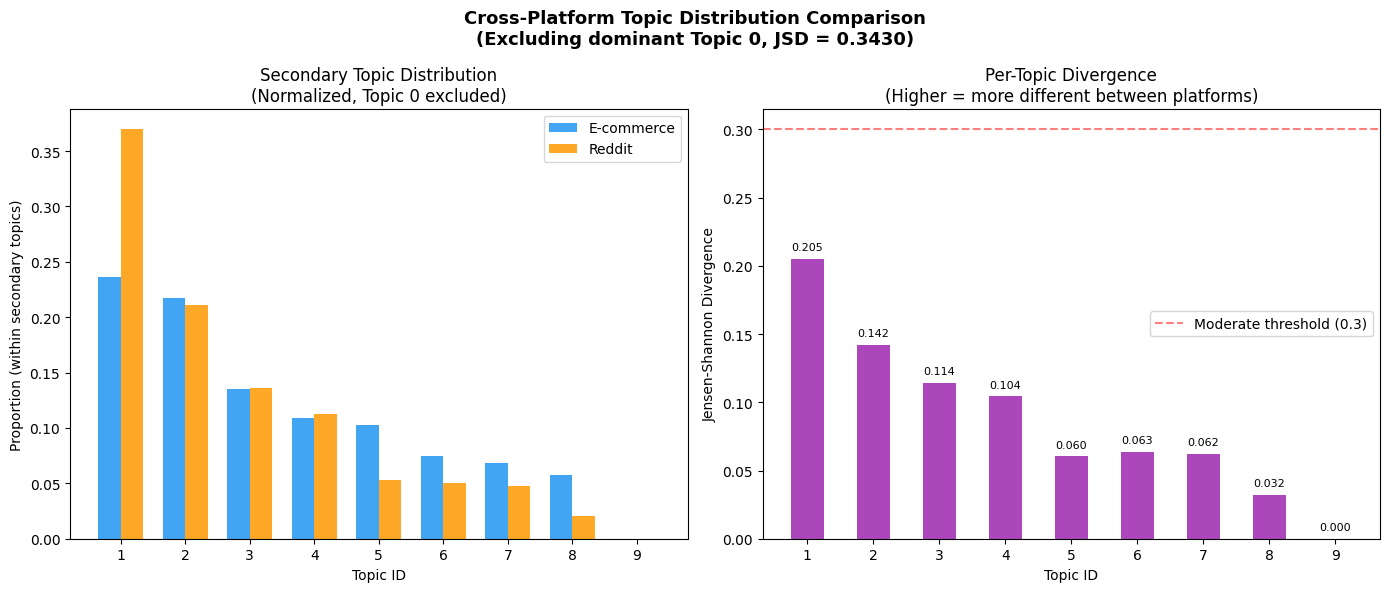

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


In [ ]:
# ── Visualization: exclude Topic 0 to show secondary topic differences ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Cross-Platform Topic Distribution Comparison\n"
             "(Excluding dominant Topic 0, JSD = 0.3430)",
             fontsize=13, fontweight="bold")

# Exclude Topic 0
ec_dist_secondary     = ec_dist[1:].copy()
reddit_dist_secondary = reddit_dist[1:].copy()

# Renormalize
ec_dist_secondary     = ec_dist_secondary / ec_dist_secondary.sum() if ec_dist_secondary.sum() > 0 else ec_dist_secondary
reddit_dist_secondary = reddit_dist_secondary / reddit_dist_secondary.sum() if reddit_dist_secondary.sum() > 0 else reddit_dist_secondary

x     = np.arange(1, n_topics)
width = 0.35

# Left: side by side bar chart
ax = axes[0]
ax.bar(x - width/2, ec_dist_secondary,     width, label="E-commerce", color="#2196F3", alpha=0.85)
ax.bar(x + width/2, reddit_dist_secondary, width, label="Reddit",     color="#FF9800", alpha=0.85)
ax.set_xlabel("Topic ID")
ax.set_ylabel("Proportion (within secondary topics)")
ax.set_title("Secondary Topic Distribution\n(Normalized, Topic 0 excluded)")
ax.legend()
ax.set_xticks(x)

# Right: JSD per topic pair
jsd_per_topic = []
for i in range(1, n_topics):
    p = np.array([ec_dist[i],     1 - ec_dist[i]])
    q = np.array([reddit_dist[i], 1 - reddit_dist[i]])
    jsd_per_topic.append(jensenshannon(p, q))

ax = axes[1]
bars = ax.bar(x, jsd_per_topic, width=0.5, color="#9C27B0", alpha=0.85)
for bar, val in zip(bars, jsd_per_topic):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Topic ID")
ax.set_ylabel("Jensen-Shannon Divergence")
ax.set_title("Per-Topic Divergence\n(Higher = more different between platforms)")
ax.set_xticks(x)
ax.axhline(y=0.3, color="red", linestyle="--", alpha=0.5, label="Moderate threshold (0.3)")
ax.legend()

plt.tight_layout()
plt.savefig("cross_platform_secondary.png", dpi=150)
plt.show()

from google.colab import files
files.download("cross_platform_secondary.png")
print("Done!")